In [167]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from typing import Tuple, List
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import numpy as np
import glob
import random
import copy


In [168]:
def show_32x32(img, title):
    """
    img: torch.Tensor or numpy array of shape (32, 32)
         values assumed in [0, 1]
    """
    # normalize to [0, 1]
    #img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img, cmap="gray_r")  # gray_r flips: 1=black, 0=white
    plt.title(title)
    plt.axis('off')
    plt.show()


In [169]:
def combineFiles(quantity, infolder, outfolder, inFeatures):
    # passed parameters are mutable in python (will be modified in function if not copied)
    inputFeatures = copy.deepcopy(inFeatures)
    if len(inFeatures) < 13:
        inputFeatures.append("FireMask")

    # List of all csv files in the specified folder)
    all_files = glob.glob(f"{infolder}/*.csv")  
    max = len(all_files)

    if quantity > max:
        print(f"Too many files requested, max {max}")
        return 0, NULL

    # shuold be able to mod this later to get train and test splits, for now just randomly selects 
    # quantity number of files from the folder
    rand_nums = random.sample(range(19), quantity)
    rand_files = [f"{infolder}/{n:02d}.csv" for n in rand_nums]

    combined_df = pd.DataFrame()
    for f in rand_files:
        curr = pd.read_csv(f)
        curr = curr[inputFeatures]
        combined_df = pd.concat([combined_df, curr])

    # Save to a single CSV
    combined_df.to_csv(f"{outfolder}/split{quantity:d}.csv", index=False)

    # return which files were chosen so those can be used for the run 
    return rand_files, f"{outfolder}/split{quantity}.csv"



In [170]:
def genFakeTarget(prevmask, hw):
    prevmask_r = prevmask.values.reshape(hw, hw, 1)
    faketarget = np.zeros((hw, hw, 1))
    ditr = np.nditer(prevmask_r, flags=['multi_index']) # n-dim iter for a matrix

    for elem in ditr:
        if elem==1:
            br = ditr.multi_index[0] # curr row
            bc = ditr.multi_index[1] # curr col
            faketarget[br][bc][0] = 1.0                                # [r][c]= 1.0 (copying prev mask fires)
            if (br - 1) >= 0: faketarget[br-1][bc][0] = 1.0     # [r-1][c]
            if (br + 1) < hw: faketarget[br+1][bc][0] = 1.0      # [r][c-1]
            if (bc - 1) >= 0: faketarget[br][bc-1][0] = 1.0     # [r][c+1]
            if (bc + 1) < hw: faketarget[br][bc+1][0] = 1.0      # [r+1][c]
            
    return faketarget

# adding pdsi range into target gen
def genFakeTarget2(prevmask, pdsi, tmmx, th, hw):
    prevmask_r = prevmask.values.reshape(hw, hw, 1)
    pdsi = pdsi.values
    tmmx = tmmx.values
    th = th.values
    faketarget = np.zeros((hw, hw, 1))
    ditr = np.nditer(prevmask_r, flags=['multi_index']) # n-dim iter for a matrix

    i = 0
    for elem in ditr:
        if elem==1 and (pdsi[i]>=-3.0 and pdsi[i]<=-2.0) and ((tmmx[i] >= 295 and tmmx[i] <=305) or (th[i]>=280 and th[i]>=310) ):
            br = ditr.multi_index[0] # curr row
            bc = ditr.multi_index[1] # curr col
            faketarget[br][bc][0] = 1.0                                # [r][c]= 1.0 (copying prev mask fires)

            if ((br - 1) >= 0) and (pdsi[i]>=-3.0 and pdsi[i]<=-2.0) and ((tmmx[i] >= 295 and tmmx[i] <=305) or (th[i]>=280 and th[i]>=310)): 
                faketarget[br-1][bc][0] = 1.0     # [r-1][c]
            if ((br + 1) < hw) and (pdsi[i]>=-3.0 and pdsi[i]<=-2.0) and ((tmmx[i] >= 295 and tmmx[i] <=305) or (th[i]>=280 and th[i]>=310)): 
                faketarget[br+1][bc][0] = 1.0      # [r][c-1]
            if ((bc - 1) >= 0) and (pdsi[i]>=-3.0 and pdsi[i]<=-2.0) and ((tmmx[i] >= 295 and tmmx[i] <=305) or (th[i]>=280 and th[i]>=310)): 
                faketarget[br][bc-1][0] = 1.0     # [r][c+1]
            if ((bc + 1) < hw) and (pdsi[i]>=-3.0 and pdsi[i]<=-2.0) and ((tmmx[i] >= 295 and tmmx[i] <=305) or (th[i]>=280 and th[i]>=310)):
                faketarget[br][bc+1][0] = 1.0      # [r+1][c]
        i=i+1
    return faketarget


In [178]:
"""Randomly axis-align crop input and output image tensors.
Args:
    crop_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    desired_size: side length (square) to crop to.
    num_in_channels: number of channels in crop_img.
    num_out_channels: number of channels in output_img.
Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
"""
def random_crop_io(input_img: torch.Tensor, output_img: torch.Tensor,
    desired_size: int, num_in_channels: int, num_out_channels: int) -> Tuple[torch.Tensor, torch.Tensor]:

    # order should be CWH (no batch dim yet!!)
    # concat first (over CHANNELS, axis=1) so that image and label will be cropped the same, then separate again
    combined = torch.cat([input_img, output_img], dim=0) # CHW ordering (channel = dim0) rather than HWC as in tf. dim same as axis
    cropTransform = transforms.RandomCrop(size=(desired_size, desired_size))
    combined = cropTransform(combined)
    
    # size CHW (channel first)
    input_img = combined[0:num_in_channels, :, :]
    output_img = combined[-num_out_channels:, :, :]

    return input_img, output_img
    
    
    
"""Center crops input and output image tensors.
Args:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    sample_size: side length (square) to crop to.
Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
"""
def center_crop_io(input_img: torch.Tensor, output_img: torch.Tensor,
    desired_size: int) -> Tuple[torch.Tensor, torch.Tensor]:

    # order is CHW not HWC as in torch so 0=channel, 1=height, 2=width
    central_fraction = desired_size / input_img.shape[1]
    cropH = int(input_img.shape[1]*central_fraction)
    cropW = int(input_img.shape[2]*central_fraction)

    cropTransform = transforms.CenterCrop(size=(cropH, cropW))
    input_img = cropTransform(input_img)
    output_img = cropTransform(output_img)

    return input_img, output_img


"""
Get mean and std from combined data from selected data split
"""
def getNormStats(combinedfile):
    df = pd.read_csv(combinedfile)
    if "FireMask" in df.columns:
        df = df.drop('FireMask', axis=1)

    std = df.std(axis=0)
    mean = df.mean(axis=0)
    return mean, std
    



In [172]:
INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']
BATCH_SIZE=32


"""
Taking out clip and normalize/clip and scale inputs and just automatically normalizing all the data. 
Adding a variable for whether fake target data should be generated
Adding a variable for the combined file for the split for normalization 
"""
class FireDataset(Dataset):
    def __init__(self, file_paths:List[str], comb_file, data_size=64, crop_size=32, in_channels=12,  
                 random_crop=True, center_crop=False,
                 fake_target=False):
        
        self.file_paths = file_paths
        self.center_crop = center_crop
        self.random_crop = random_crop
        self.data_size = data_size
        self.crop_size = crop_size
        self.in_channels = in_channels
        self.comb_file = comb_file
        self.fake_target = fake_target

        # read in all samples at once: leave preprocessing to getitem() method
        # if fake_target is false, fake labels will be all -5. if its true, both fake and real labels 
        # will have data in them
        self.in_images = []
        self.fake_labels = []
        self.real_labels = [] 

        #self.base_dir = "C:\\Users\\rball\\OneDrive\\Documents\\school\\00 GRADUATE\\Thesis\\"
        for file in self.file_paths:
            #curr_file = self.base_dir + file
            df = pd.read_csv(file)

            # target/label processing
            if self.fake_target is True:
                ftarget = genFakeTarget2(df["PrevFireMask"], df['pdsi'], df['tmmx'], df['th'], data_size)
                #ftarget = genFakeTarget(df["PrevFireMask"], data_size)
                ftarget = np.array(ftarget).reshape(64, 64, 1)
                flabel = torch.tensor(ftarget, dtype=torch.float32).permute(2,0,1)
                self.fake_labels.append(flabel)

            else: self.fake_labels.append(torch.full((data_size, data_size, 1), -5.0)) # fill with obv incorrect vals when fake_target is false

            # can't just select the first column since they are not always in order
            rtarget = df["FireMask"].astype(np.float32)
            rtarget[rtarget == -1] = 0.0 # replacing "ambiguous" placeholder with "no fire" val
            rtarget = np.array(rtarget).reshape(data_size, data_size, 1)
            rlabel = torch.tensor(rtarget, dtype=torch.float32).permute(2,0,1)
            self.real_labels.append(rlabel)

            # other feature processing
            data = df.drop('FireMask', axis=1).astype(np.float32)
            data = data[INPUT_FEATURES] # sort features into consistent order
            mean, std = getNormStats(self.comb_file) # get mean and std from combined file of entered filepaths
            data_norm = (data - mean)/std

            data_norm = data.values.reshape(data_size, data_size, 12)
            
            # permute to get in shape CHW. DONT unsqueeze for batch dim as that is added by DataLoader!!!!
            image = torch.tensor(data_norm, dtype=torch.float32).permute(2,0,1)
            self.in_images.append(image) 
   

    def __len__(self):
        return len(self.file_paths)
    

    def __getitem__(self, idx): # GETITEM RETURNS WITH SIZE CHW
        # in_images is already a list of tensors in the correct shape
        input_img = self.in_images[idx]
        r_output_img = self.real_labels[idx]
        f_output_img = self.fake_labels[idx]

        if self.random_crop and self.center_crop:
            raise ValueError('Cannot have both random_crop and center_crop be True')

        # CROP METHODS NOT CURRENTLY SET TO WORK WITH FAKE DATA TARGET
        if self.random_crop:
            input_img, r_output_img = random_crop_io(input_img, r_output_img, desired_size=self.crop_size, 
                                        num_in_channels=self.in_channels, num_out_channels=1)
        elif self.center_crop:
            input_img, r_output_img = center_crop_io(input_img, r_output_img, desired_size=self.crop_size)
            
        #print("input shape:", input_img.shape, " output shape:", output_img.shape )
        return input_img, r_output_img, f_output_img
        


In [179]:
# FOR MODEL TESTING
split5files, s5_combFile = combineFiles(5, "../03DataVisualization/renamed-raw-csvs", "../03DataVisualization/combo-files-for-norm", INPUT_FEATURES)
split5_dataset = FireDataset(split5files, s5_combFile, random_crop=False, center_crop=False, fake_target=True)
split5_dataloader = DataLoader(split5_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(split5files)


# FOR HEATMAP VIZ
# split19files, s19_combFile = combineFiles(19, "../03DataVisualization/renamed-raw-csvs", "../03DataVisualization/combo-files-for-norm", INPUT_FEATURES)
# split19_dataset = FireDataset(split19files, s19_combFile, random_crop=False, center_crop=False, fake_target=False)
# split19_dataloader = DataLoader(split19_dataset, batch_size=BATCH_SIZE, shuffle=True)

['../03DataVisualization/renamed-raw-csvs/03.csv', '../03DataVisualization/renamed-raw-csvs/17.csv', '../03DataVisualization/renamed-raw-csvs/18.csv', '../03DataVisualization/renamed-raw-csvs/06.csv', '../03DataVisualization/renamed-raw-csvs/15.csv']


In [174]:
hw_size = 64 # not cropping for now
c_size = 12

class WildfireMLP(nn.Module):
    def __init__(self, hw_size, c_size):
        super().__init__() # calling/initializing the nn Module

        #assuming right now that input will be passed as B, 12, hwsize, hwsize
        self.flatten = nn.Flatten(start_dim=1)

        # pick some arbitrary size for inner layers, say 2000 just for funsies
        # output needs to be hw*hw for spatial image
        self.linear1 = nn.Linear(in_features=(hw_size*hw_size*c_size), out_features=2000)
        # changing weight initialization
        nn.init.kaiming_uniform_(self.linear1.weight, nonlinearity='relu')

        self.bn1 = nn.BatchNorm1d(num_features=2000)
        self.relu1 = nn.ReLU()

        self.linear2 = nn.Linear(2000,2000)
        self.bn2 = nn.BatchNorm1d(num_features=2000)
        self.relu2 = nn.ReLU()

        self.linear3 = nn.Linear(2000,2000)
        self.bn3 = nn.BatchNorm1d(num_features=2000)
        self.relu3 = nn.ReLU()

        self.linear4 = nn.Linear(2000, hw_size*hw_size)
        self.sigmoid = nn.Sigmoid()
        # self.bn4 = nn.BatchNorm1d(num_features=hw_size*hw_size)
        # self.lastRelu = nn.ReLU()

        # unflatten
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(1, hw_size, hw_size))

    def forward(self, x):
        x = self.flatten(x)

        x = self.linear1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.linear2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.linear3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.linear4(x)
        x = self.sigmoid(x)

        # unflatten
        x = self.unflatten(x)
 
        return x



Epoch [1/10]  Loss: 0.713385
Epoch [2/10]  Loss: 0.384164
Epoch [3/10]  Loss: 0.195587
Epoch [4/10]  Loss: 0.094752
Epoch [5/10]  Loss: 0.050524
Epoch [6/10]  Loss: 0.028667
Epoch [7/10]  Loss: 0.017124
Epoch [8/10]  Loss: 0.010617
Epoch [9/10]  Loss: 0.006731
Epoch [10/10]  Loss: 0.004365


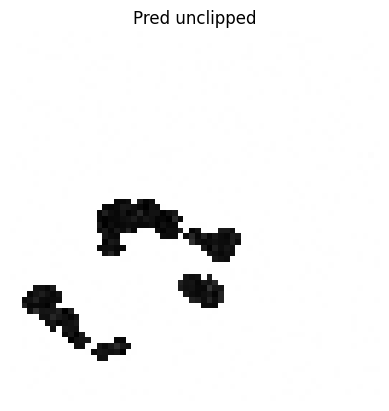

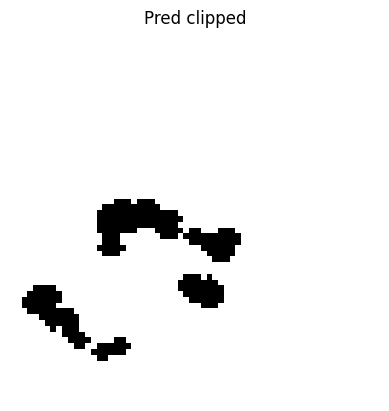

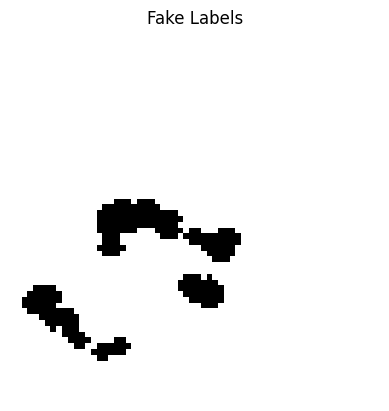

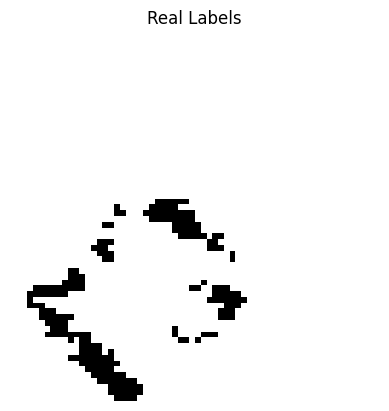

In [180]:
import torch.optim as optim
numepochs = 10
model = WildfireMLP(hw_size, c_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loader = split5_dataloader

ftarget = True

for epoch in range(numepochs):
    model.train()
    running_loss = 0.0
    
    for inputs, rlabels, flabels in loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        
        if ftarget: labels=flabels
        else: labels=rlabels

        labels[labels==-1]=0
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # weight loss by batch size which may change
        running_loss += loss.item()*inputs.size(0) 

    epoch_lossavg = running_loss/len(loader.dataset)
    print(f"Epoch [{epoch+1}/{numepochs}]  Loss: {epoch_lossavg:.6f}")

out_clip = (outputs>=0.5).int()
show_32x32(outputs.detach().numpy()[0,0,:,:], "Pred unclipped")
show_32x32(out_clip.detach().numpy()[0,0,:,:], "Pred clipped")
show_32x32(flabels[0,0,:,:], "Fake Labels")
show_32x32(rlabels[0,0,:,:], "Real Labels")

### EDA: Spearman correlation analysis
Next section runs spearman correlation on each datafile. Pandas corr method returns an fxf table for correlation for  
every feature with every other feature; full tables for each file are saved in new csv files. The first line of each  
(correlation between each variable and FireMask) was saved to a new dataframe to be printed and put into an excel  
sheet for more analysis. The point of this was originally to figure out which variables to start with for fake  
target generation rules

In [176]:
INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']
INPUT_FEATURES.insert(0,"FireMask")
pd.set_option("display.expand_frame_repr", False)

corrtable = pd.DataFrame()
for i in range(19):
    filename = f"../03DataVisualization/renamed-raw-csvs/{i:02d}.csv"
    df = pd.read_csv(filename)
    df = df[INPUT_FEATURES]
    ctable = df.corr(method='spearman')
    corrtable = pd.concat((corrtable, ctable.head(1)), axis=0)
    ctable.to_csv(f"../03DataVisualization/spearman-correlation-tables/{i:02d}_scorr.csv")

#print(corrtable)

INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']

### EDA: Heatmap visualization
method copied almost directly from the pytorch/tf model code

In [177]:
def plot_samples_from_dataset(dataset: torch.utils.data.Dataset, n_rows: int): 
    TITLES = ['Elevation',
                'Wind\ndirection (th)',
                'Wind\nvelocity (vs)',
                'Min\ntemp',
                'Max\ntemp',
                'Humidity (sph)',
                'Precip (pr)',
                'Drought (pdsi)',
                'Vegetation (ndvi)',
                'Population\ndensity',
                'Energy\nrelease\ncomponent (erc)',
                'Previous\nfire\nmask',
                'Fire\nmask']

    fig = plt.figure(figsize=(25, 2*n_rows))

    # Colormap for the fire masks
    CMAP = colors.ListedColormap(['black', 'silver', 'orangered'])
    BOUNDS = [-1, -0.1, 0.001, 1]
    NORM = colors.BoundaryNorm(BOUNDS, CMAP.N)

    for i, (inputs, labels) in enumerate(dataset):
        if i >= n_rows:
            break
        
        n_features = inputs.shape[0]  # number of channels
        
        for j in range(n_features + 1):  # +1 for label column
            plt.subplot(n_rows, n_features + 1, i * (n_features + 1) + j + 1)
            
            # Title only for first row
            if i == 0:
                if j < n_features:
                    plt.title(TITLES[j], fontsize=13)
                else:
                    plt.title("Label", fontsize=13)
            
            # Input channels
            if j < n_features - 1:
                img = inputs[j, :, :].cpu().numpy()
                plt.imshow(img, cmap='viridis')
            
            # Second-to-last input channel and label
            if j >= n_features - 1:
                img = inputs[j, :, :].cpu().numpy() if j == n_features - 1 else labels[0, :, :].cpu().numpy()
                plt.imshow(img, cmap=CMAP, norm=NORM)
            
            plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_samples_from_dataset(split19_dataset, 19)


NameError: name 'split19_dataset' is not defined

### Attempt at CAE (doesn't work right now)

In [ ]:
class CAutoencoder(nn.Module):
    def __init__(self, inChannels=12):
        super().__init__()

        """ encoder """
        # following input -> (conv, relu, pool) pattern
        self.enc_conv1 = nn.Conv2d(in_channels=inChannels, out_channels=32, kernel_size=3, stride=1, padding=1) # C_out=32, maintain spatial
        self.enc_mp1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # spatial decrease by factor of 2, channels maintained
        self.enc_relu1 = nn.ReLU()
        self.enc_conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1) # C_out doubled, spatial maintained
        self.enc_mp2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # spatial decrease by half, channels maintained
        self.enc_relu2 = nn.ReLU()
        # if input is (12x64x64), output should now be (64x16x16)
        # not flattening, keeping last spatial size in bottleneck
        

        """ decoder """
        self.dec_mup1 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.dec_relu1 = nn.ReLU()

        self.dec_mup2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv2 = nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1)
        self.dec_sig = nn.Sigmoid()
        # opposite of encoder but final out channels is 1
        

    def forward(self, x):
        x = self.enc_conv1(x)
        x, idx1 = self.enc_mp1(x)
        x = self.enc_relu1(x)

        x = self.enc_conv2(x)
        x, idx2 = self.enc_mp2(x)
        enc_out = self.enc_relu2(x)

        # unpooling have to be reversed to get spatials right
        y = self.dec_mup2(enc_out, idx2)
        y = self.dec_conv1(y)
        y = self.dec_relu1(y)

        y = self.dec_mup1(y, idx1)
        y = self.dec_conv2(y)
        dec_out = self.dec_sig(y)
        return dec_out